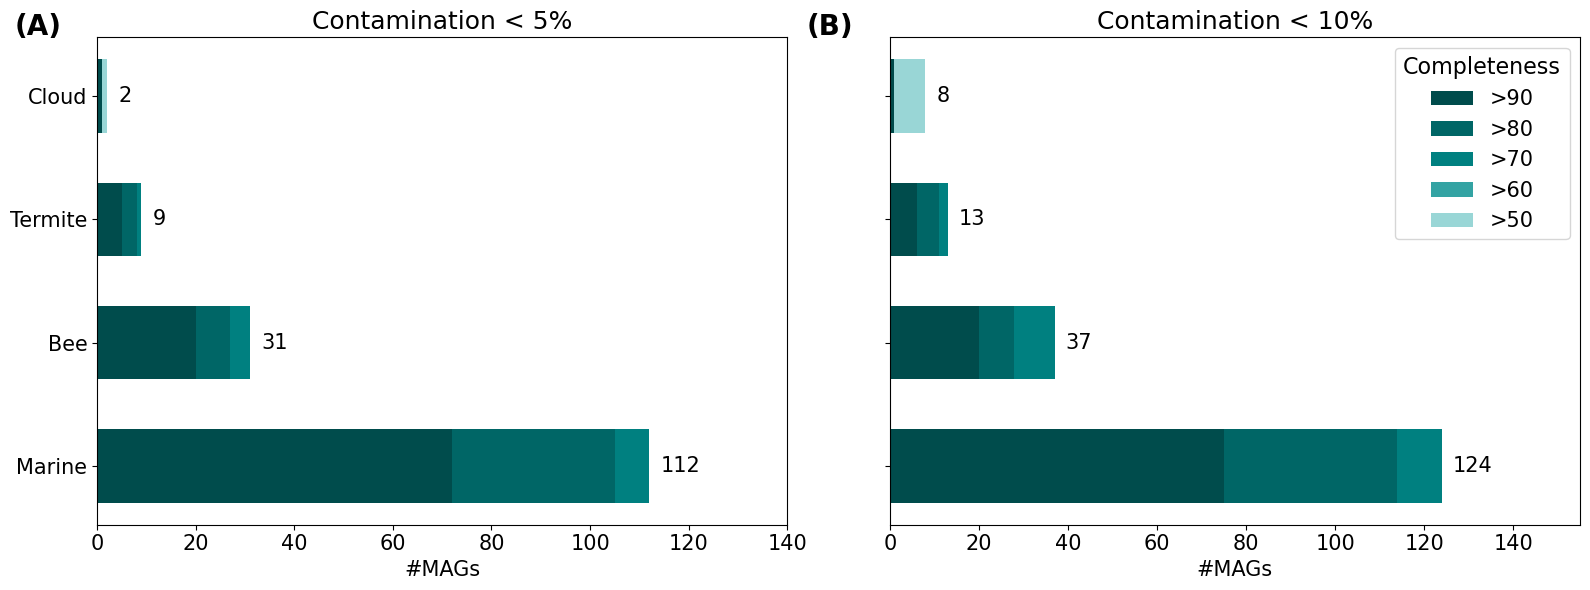

Bee: dRep found 161 MAGs
Cloud: dRep found 230 MAGs
Termite: dRep found 24 MAGs
Marine: dRep found 153 MAGs


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

files = {
    "Bee": "input/bee/checkm2.tsv",
    "Cloud": "input/cloud/checkm2.tsv",
    "Termite": "input/termite/checkm2.tsv",
    "Marine": "input/marine/checkm2.tsv",
}

drep_files = { 
    "Bee": "input/bee/drep.csv",
    "Cloud": "input/cloud/drep.csv",
    "Termite": "input/termite/drep.csv",
    "Marine": "input/marine/drep.csv",
}

thresholds = [">90", ">80", ">70", ">60", ">50"]
colors = ["#004c4c", "#006666", "#008080", "#33a3a3", "#99d6d6"]

def count_drep_bins(filename):
    count = 0
    with open(filename, "r") as f:
        for i, line in enumerate(f):
            if i == 0 or not line.strip():
                continue
            count += 1
    return count

def assign_threshold(comp):
    if comp >= 90:
        return ">90"
    elif comp >= 80:
        return ">80"
    elif comp >= 70:
        return ">70"
    elif comp >= 60:
        return ">60"
    elif comp >= 50:
        return ">50"
    return None

def load_counts(cont_cutoff):
    result = {thr: [] for thr in thresholds}
    totals = []

    for usecase, f in files.items():
        df = pd.read_csv(f, sep="\t")
        df2 = df[df["Contamination"] < cont_cutoff].copy()
        df2["Thr"] = df2["Completeness"].apply(assign_threshold)

        counts = df2["Thr"].value_counts()

        total = 0
        for thr in thresholds:
            val = counts.get(thr, 0)
            result[thr].append(val)
            total += val

        totals.append(total)

    usecases = list(files.keys())
    sorting_idx = np.argsort(totals)[::-1]

    sorted_use_cases = [usecases[i] for i in sorting_idx]
    sorted_result = {
        thr: [result[thr][i] for i in sorting_idx]
        for thr in thresholds
    }

    return sorted_use_cases, sorted_result

def plot_stacked(ax, tools, data, title):
    y = np.arange(len(tools))
    left = np.zeros(len(tools))

    for i, thr in enumerate(thresholds):
        values = data[thr]
        ax.barh(
            y,
            values,
            left=left,
            color=colors[i],
            label=thr,
            height=0.6
        )
        left += np.array(values)

    for i in range(len(tools)):
        ax.text(
            left[i] + (max(left) * 0.02),
            i,
            str(int(left[i])),
            va="center",
            ha="left",
            fontsize=15
        )

    ax.set_xlim(0, max(left) * 1.25)
    ax.set_yticks(y)
    ax.set_yticklabels(tools, fontsize=15)
    ax.set_xlabel("#MAGs", fontsize=15)
    ax.set_title(title, fontsize=18)
    ax.tick_params(axis="x", labelsize=15)

# Load data
use_cases, data5 = load_counts(cont_cutoff=5)
_, data10 = load_counts(cont_cutoff=10)

# Side-by-side plots
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

plot_stacked(axs[0], use_cases, data5, "Contamination < 5%")
plot_stacked(axs[1], use_cases, data10, "Contamination < 10%")

# Panel labels
axs[0].text(
    -0.12, 1.05, "(A)",
    transform=axs[0].transAxes,
    fontsize=20,
    fontweight="bold",
    va="top",
    ha="left"
)

axs[1].text(
    -0.12, 1.05, "(B)",
    transform=axs[1].transAxes,
    fontsize=20,
    fontweight="bold",
    va="top",
    ha="left"
)

# Legend
axs[1].legend(
    title="Completeness",
    loc="upper right",
    fontsize=15,
    title_fontsize=16
)

plt.tight_layout()
plt.savefig("combined_bar_plot.png", dpi=300)
plt.show()

for uc in drep_files:
    print(f"{uc}: dRep found {count_drep_bins(drep_files[uc])} MAGs")


# Generate summary table for MAGs assessment


In [12]:
import pandas as pd
import pathlib

# ================= CONFIG =================
folders = ["bee", "cloud", "marine", "termite"]

# =========================================
for folder in folders:
    print(f"\nProcessing {folder}")
    folder_path = pathlib.Path(f"../{folder}")

    # ---------- dRep ----------
    drep = pd.read_csv(folder_path / "drep.csv")
    drep["genome"] = drep["genome"].str.replace(r"\.fasta$", "", regex=True)

    # cluster size
    cluster_sizes = (
        drep.groupby("secondary_cluster")
        .size()
        .rename("cluster_size")
        .reset_index()
    )

    # ---------- CheckM2 ----------
    checkm = pd.read_csv(folder_path / "checkm2.tsv", sep="\t")
    checkm["Name"] = checkm["Name"].str.replace(r"\.fasta$", "", regex=True)

    # keep only genomes present in dRep
    checkm = checkm[checkm["Name"].isin(drep["genome"])]

    # ---------- merge dRep + CheckM2 ----------
    merged = pd.merge(
        checkm,
        drep,
        left_on="Name",
        right_on="genome",
        how="left"
    )

    merged = pd.merge(
        merged,
        cluster_sizes,
        on="secondary_cluster",
        how="left"
    )

    # ---------- GTDB ----------
    gtdb = pd.read_csv(folder_path / "gtdb.tsv", sep="\t")
    gtdb["user_genome"] = gtdb["user_genome"].str.replace(r"\.fasta$", "", regex=True)

    merged = pd.merge(
        merged,
        gtdb[["user_genome", "classification"]],
        left_on="Name",
        right_on="user_genome",
        how="left"
    )

    # split GTDB taxonomy
    tax_ranks = ["domain", "phylum", "class", "order", "family", "genus", "species"]

    def split_taxonomy(tax):
        if pd.isna(tax):
            return pd.Series([None] * 7)
        parts = tax.split(";")
        parts = [p.split("__", 1)[-1] if "__" in p else None for p in parts]
        return pd.Series(parts + [None] * (7 - len(parts)))

    merged[tax_ranks] = merged["classification"].apply(split_taxonomy)

    # ---------- QUAST ----------
    quast = pd.read_csv(
        folder_path / "quast.tsv",
        sep="\t",
        comment="#",
        index_col=0
    )

    quast = quast.T.reset_index().rename(columns={"index": "Name"})
    quast["Name"] = quast["Name"].str.replace(r"\.fasta$", "", regex=True)

    merged = pd.merge(
        merged,
        quast,
        on="Name",
        how="left"
    )

    # ---------- BAKTA ----------
    bakta_raw = pd.read_csv(folder_path / "bakta.tsv", sep="\t")
    bakta_raw = bakta_raw.rename(columns={bakta_raw.columns[0]: "annotation"})
    bakta_raw = bakta_raw[bakta_raw["annotation"] != "Annotation"]
    bakta_raw = bakta_raw.set_index("annotation")

    bakta = bakta_raw.T.reset_index().rename(columns={"index": "Name"})
    bakta["Name"] = (
        bakta["Name"]
        .str.replace(r"\.fasta_2$", "", regex=True)
        .str.replace(r"\.fasta$", "", regex=True)
    )

    merged = pd.merge(
        merged,
        bakta,
        on="Name",
        how="left"
    )

    # ---------- FINAL COLUMN ORDER ----------
    core_cols = [
        "Name",
        "secondary_cluster",
        "cluster_size",
        "Completeness",
        "Contamination",
        "Genome_Size",
        "GC_Content",
        "domain",
        "phylum",
        "class",
        "order",
        "family",
        "genus",
        "species",
    ]

    other_cols = [c for c in merged.columns if c not in core_cols]
    merged = merged[core_cols + other_cols]

    # ---------- SAVE ----------
    out_file = folder_path / "genome_cluster_annotation_table.tsv"
    merged.to_csv(out_file, sep="\t", index=False)

    print(f"Saved: {out_file}")



Processing bee
Saved: ../bee/genome_cluster_annotation_table.tsv

Processing cloud
Saved: ../cloud/genome_cluster_annotation_table.tsv

Processing marine
Saved: ../marine/genome_cluster_annotation_table.tsv

Processing termite
Saved: ../termite/genome_cluster_annotation_table.tsv
